# 沐曦 GPU 运行 Lingshu-7B 说明文档
[Lingshu-7B](https://huggingface.co/lingshu-medical-mllm/Lingshu-7B) 是面向医学多模态理解与推理的视觉语言模型，基于 Qwen2.5-VL 架构，支持医学图像问答、图像描述和报告生成等研究任务。模型卡列举的医学影像模态包括 X-Ray、CT、MRI、显微镜、超声、组织病理、眼底和内镜等。

本教程复现模型卡中的 Transformers 推理路径：读取本地医学图像，使用对话模板和视觉输入处理器构造多模态输入，在沐曦 GPU 上调用 `generate`，并显示模型原始文本输出及本次运行的设备、耗时和显存信息。模型输出可能存在幻觉、遗漏或不确定性；本教程仅用于工程/研究验证，不用于诊断、治疗、临床决策、患者服务或监管提交。

[Lingshu-7B](https://huggingface.co/lingshu-medical-mllm/Lingshu-7B) 由上游项目以 MIT 许可证发布，我方未对其模型权重、源代码或模型语义作任何修改。您可通过模型页面查阅上游模型卡、许可证、版权与归属声明及其他项目文档。

- 模型页面：<https://huggingface.co/lingshu-medical-mllm/Lingshu-7B>
- 技术报告：<https://arxiv.org/abs/2506.07044>
- 权重、模型卡和示例图像由上游发布，本目录不复制权重或患者数据。
- 默认输入是模型目录中的 `example.png`。如果使用其他图像，请确认其来源、授权和隐私边界，并通过 `LINGSHU_IMAGE_PATH` 指向本地文件。不要把未经授权的患者图像提交到 Notebook 或代码仓库。

## 1. 安装

### 1.1 沐曦容器

使用已经包含 MACA 版 PyTorch 与 torchvision 的沐曦基础镜像；镜像名称、端口和共享目录按目标机器替换：

```bash
docker run -it --name lingshu-notebook \
  --device=/dev/mxcd \
  --group-add video --shm-size=16G \
  --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -p 127.0.0.1:8888:8888 -v /workspace:/workspace \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

### 1.2 安装 Python 依赖

保留基础镜像中的 MACA `torch` 和 `torchvision`，在容器内安装模型调用所需的公开 Python 包：

```bash
python -m pip install transformers qwen-vl-utils Pillow jupyter
```

请先从上游模型页面准备完整的 `Lingshu-7B` 本地目录，并确保该目录包含模型权重、配置、processor/tokenizer 文件；示例图像可使用模型目录中的 `example.png`。本教程不在 Notebook 中自动下载权重或修改运行环境。

### 1.3 运行参数

下面是 Notebook 的唯一参数锚点。模型路径、输入图像、设备、数据类型和生成参数均由此单元格驱动；需要替换资产时只修改这里或对应环境变量。`local_files_only=True` 保证实际推理不隐式联网下载。运行时日志写入可写的临时 HOME（可通过 `LINGSHU_RUNTIME_HOME` 修改），避免 MACA 尝试在根目录创建 `mxlog/umd`。

In [1]:
import os
import time
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
runtime_home = Path(os.environ.get("LINGSHU_RUNTIME_HOME", "/tmp/lingshu-home")).expanduser()
(runtime_home / "mxlog" / "umd").mkdir(parents=True, exist_ok=True)
os.environ["HOME"] = str(runtime_home)

MODEL_ID = "lingshu-medical-mllm/Lingshu-7B"
MODEL_PATH = Path(os.environ.get("LINGSHU_MODEL_PATH", "/workspace/models/Lingshu-7B")).expanduser()
default_image_path = MODEL_PATH / "example.png"
IMAGE_PATH = Path(os.environ.get("LINGSHU_IMAGE_PATH", str(default_image_path))).expanduser()
DEVICE = "cuda:0"
QUESTION = os.environ.get(
    "LINGSHU_QUESTION",
    "Describe this image. Do not provide a diagnosis or treatment recommendation.",
).strip()
MAX_NEW_TOKENS = int(os.environ.get("LINGSHU_MAX_NEW_TOKENS", "128"))
DO_SAMPLE = False

print("Model ID:", MODEL_ID)
print("Model path:", MODEL_PATH)
print("Image path:", IMAGE_PATH)
print("Device:", DEVICE)
print("Question:", QUESTION)
print("Generation:", {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": DO_SAMPLE})

Model ID: lingshu-medical-mllm/Lingshu-7B
Model path: /workspace/models/Lingshu-7B
Image path: /workspace/models/Lingshu-7B/example.png
Device: cuda:0
Question: Describe this image. Do not provide a diagnosis or treatment recommendation.
Generation: {'max_new_tokens': 128, 'do_sample': False}


PyTorch version: 2.6.0+metax3.8.0.7
GPU: MetaX C500
GPU memory: 60.9/63.6 GiB free
Image size: (1844, 1504)


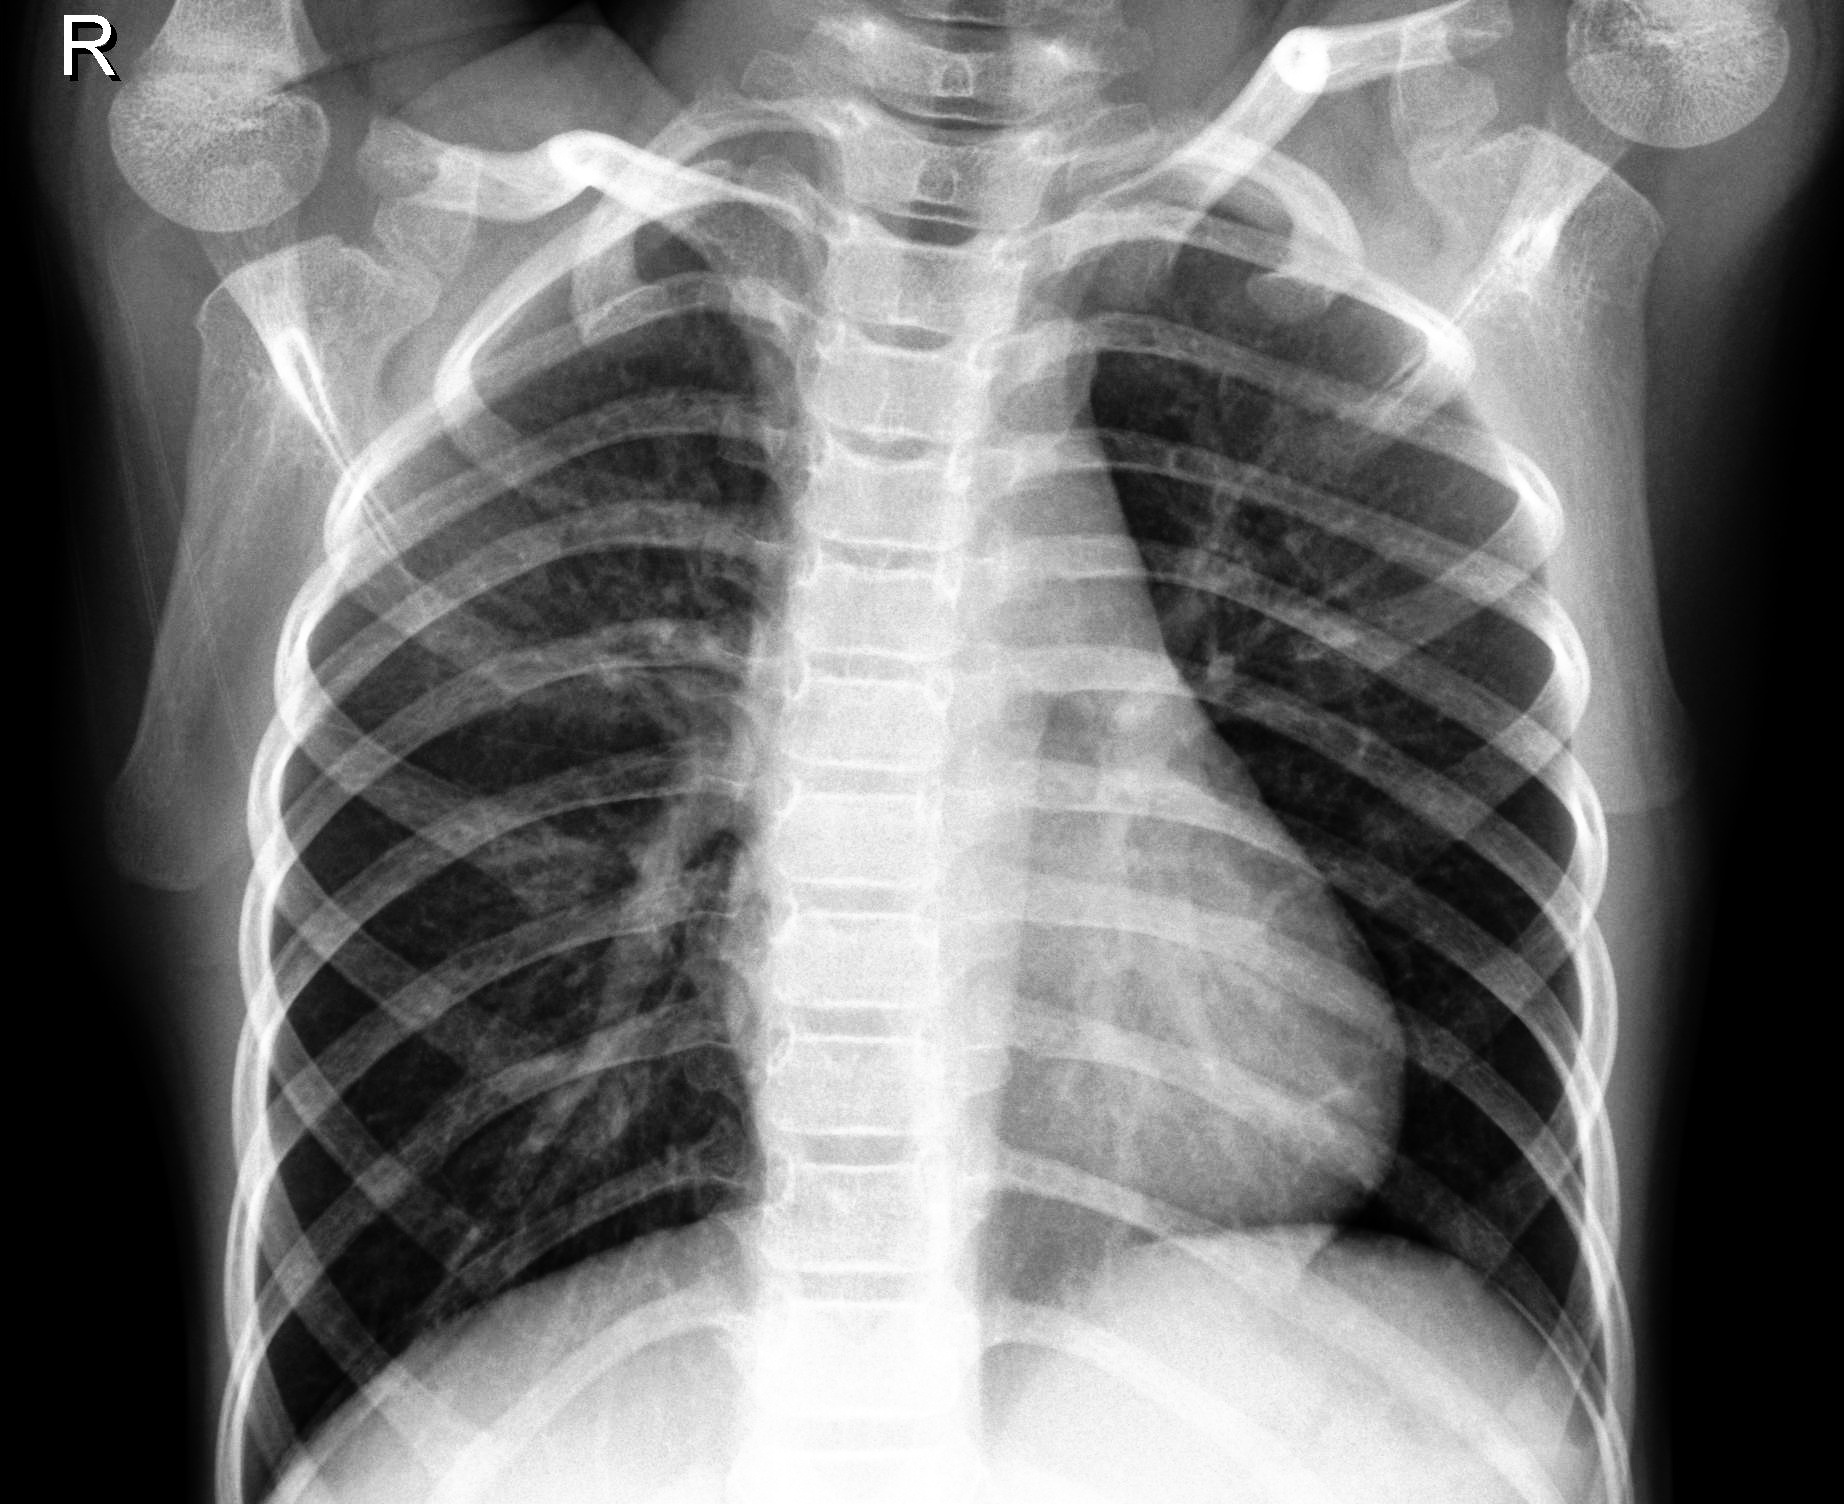

In [2]:
import torch
from IPython.display import display
from PIL import Image

if not torch.cuda.is_available():
    raise RuntimeError("未检测到沐曦 GPU，请检查 MACA 容器的设备映射。")
if not MODEL_PATH.is_dir():
    raise FileNotFoundError(f"模型目录不存在：{MODEL_PATH}")
if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"输入图像不存在：{IMAGE_PATH}")

image = Image.open(IMAGE_PATH).convert("RGB")
free_memory, total_memory = torch.cuda.mem_get_info(0)
print("PyTorch version:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print(f"GPU memory: {free_memory / 2**30:.1f}/{total_memory / 2**30:.1f} GiB free")
print("Image size:", image.size)
display(image)

## 2. 沐曦 GPU 运行效果显示

以下代码沿用 Lingshu 官方 Transformers 示例的 `Qwen2_5_VLForConditionalGeneration`、`AutoProcessor`、`process_vision_info` 和 `generate` 调用链。为适配 MACA 环境，默认使用 PyTorch 的 `cuda:0` 设备接口，不强制打开可能未在当前镜像中提供的 FlashAttention；这不改变模型输入、对话模板或输出裁剪语义。运行后输出的回答、耗时和峰值显存均来自本次 Notebook 进程。

In [3]:
import warnings

from qwen_vl_utils import process_vision_info
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils import logging as transformers_logging

warnings.filterwarnings("ignore", category=FutureWarning, module=r"transformers\..*")
warnings.filterwarnings("ignore", category=UserWarning, module=r"torchvision\..*")
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

load_started = time.perf_counter()
processor = AutoProcessor.from_pretrained(
    MODEL_PATH,
    local_files_only=True,
)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    local_files_only=True,
).eval().to(DEVICE)

print("Model loaded on:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)
print(f"Model load time: {time.perf_counter() - load_started:.3f} s")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/conda/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/opt/conda/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https:/

Model loaded on: cuda:0
Model dtype: torch.bfloat16
Model load time: 12.448 s


In [4]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(IMAGE_PATH)},
            {"type": "text", "text": QUESTION},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
).to(DEVICE)

print("Prompt tokens:", inputs.input_ids.shape[-1])
print("Pixel values shape:", tuple(inputs.pixel_values.shape))

Prompt tokens: 3598
Pixel values shape: (14256, 1176)


In [5]:
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
inference_started = time.perf_counter()
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
    )
torch.cuda.synchronize()

generated_ids_trimmed = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0].strip()
elapsed = time.perf_counter() - inference_started
peak_memory = torch.cuda.max_memory_allocated() / 2**30

print("## Lingshu-7B 原始输出")
print(output_text)
print()
print(f"Generated tokens: {generated_ids_trimmed[0].shape[-1]}")
print(f"Inference time: {elapsed:.3f} s")
print(f"Peak allocated memory: {peak_memory:.3f} GiB")

## Lingshu-7B 原始输出
The provided chest X-ray image shows a frontal view of the thoracic cavity. The bony structures, including the ribs and vertebrae, appear intact without any obvious fractures or deformities. The lung fields are visible, with no apparent consolidation, masses, or significant opacities that would suggest pneumonia or other pulmonary pathologies. The heart silhouette is within normal limits in size and shape, indicating no overt cardiomegaly. The diaphragm appears well-defined, and there is no evidence of free air under the diaphragm, which would suggest pneumoperitoneum. Overall, the image does not show acute abnormalities, but

Generated tokens: 128
Inference time: 9.301 s
Peak allocated memory: 16.318 GiB


### 结果说明

上面的文本是模型对当前本地图像和 `QUESTION` 的原始生成结果；它不是人工校验过的医学结论。需要尝试其他研究问题时，修改参数锚点中的 `LINGSHU_QUESTION` 或 `QUESTION` 后，从参数单元开始重新执行后续单元，确保图像、问题和回答来自同一次推理。

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.